In [1]:
import tensorflow_datasets as tfds
#import tensorflow_text as tf_text
from datetime import datetime
#!pip install tensorflow_datasets
#!pip install tensorflow-text
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Embedding,Dense,Conv2D,MaxPooling2D,Input,InputLayer,UpSampling2D,Flatten,Conv2DTranspose,Reshape
from tensorflow.keras import Sequential,layers
from keras.layers import LSTM
from tensorflow.keras import losses
import pandas as pd
print(tf.__version__)

c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



2.15.0


# Autoencoders

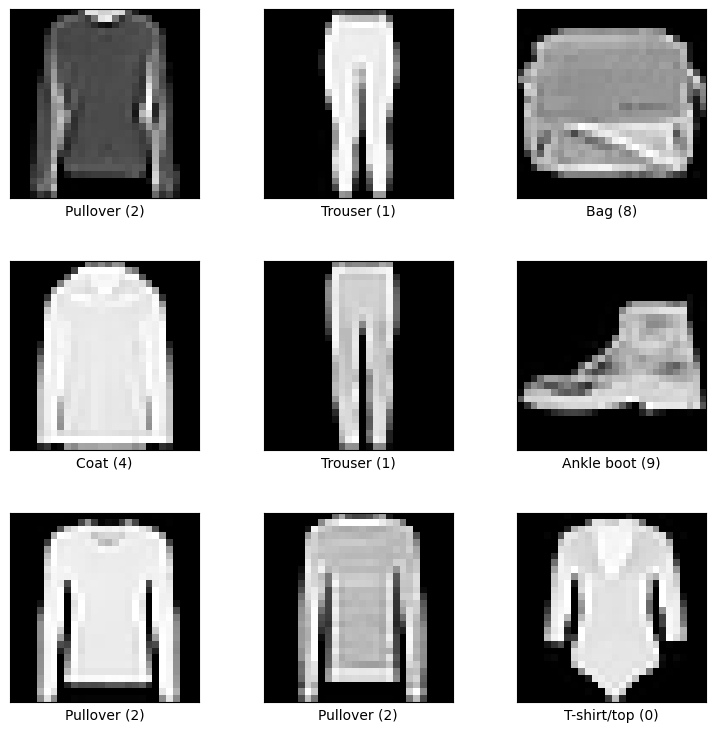

In [2]:
(ds_train_, ds_val_,ds_test_,ds_unseen), ds_info = tfds.load(
    name = 'fashion_mnist',
    split=['train[:50%]', 'train[50%:60%]','train[60%:70%]','train[70%:80%]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True)
fig = tfds.show_examples(ds_train_, ds_info)


In [5]:
ds_train_

<_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [4]:
label_names = ds_info.features['label'].names
label_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
def augment_data(images, labels, get_label=False):
    if get_label:
        return tf.cast(images, tf.float32) / 255.,labels
    else:
        return tf.cast(images, tf.float32) / 255.,tf.cast(images, tf.float32) / 255.

In [8]:
#img,labels -> img_norma, labels (get_label=True)
#img,labels -> img_norma, img_norma (get_label=False)

In [9]:
def data_load(data_ds,augmented=augment_data,shuffle_=True ,batch_=10,get_label=False):
    data_ds = data_ds.map(lambda x,y:
        augmented(x,y,get_label), num_parallel_calls=tf.data.AUTOTUNE)
    data_ds = data_ds.cache()
    if shuffle_:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

data_train = data_load(ds_train_)
data_val = data_load(ds_val_)
data_test = data_load(ds_test_,shuffle_=False)

data_unseen = data_load(ds_unseen, get_label=True )

In [16]:
for ds,lb in data_train.take(1): 
    shaped=ds.shape
print(shaped)

(10, 28, 28, 1)


In [17]:
encoded_size=2
base_depth = 16

encoder = Sequential([
    InputLayer(input_shape=shaped[1:]),
    Conv2D(base_depth, 3, 
                padding='same', activation='relu'),
    MaxPooling2D((2, 2), padding='same'),
    
    Conv2D(base_depth//2, 3, 
                padding='same', activation='relu'),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(base_depth//2, 3, 
                padding='same', activation='relu'),
    MaxPooling2D((2, 2), padding='same'),
    Flatten(),
    Dense(encoded_size,name='encoder'),
])

In [18]:
encoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 8)         1160      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 8)           0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 8)           584       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 4, 4, 8)           0

In [21]:
decoder = Sequential([
    InputLayer(input_shape=[encoded_size,]),
    Dense(128),
    Reshape((4, 4,8)),
    Conv2D(base_depth//2, 3, 
                         padding='same', activation='relu'),
    UpSampling2D((2, 2)),
    Conv2D(base_depth//2, 3, 
                         padding='same', activation='relu'),
    UpSampling2D((2, 2)),
    Conv2D(base_depth, 3, activation='relu'),
    UpSampling2D((2, 2)),
    Conv2D(filters=1, kernel_size=3,
                padding='same', activation='sigmoid'),
],name='decoder')

In [22]:
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 128)               384       
                                                                 
 reshape_1 (Reshape)         (None, 4, 4, 8)           0         
                                                                 
 conv2d_7 (Conv2D)           (None, 4, 4, 8)           584       
                                                                 
 up_sampling2d_3 (UpSamplin  (None, 8, 8, 8)           0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 8, 8, 8)           584       
                                                                 
 up_sampling2d_4 (UpSamplin  (None, 16, 16, 8)         0         
 g2D)                                                      

In [23]:
autoencoder= tf.keras.Model(inputs= encoder.inputs, outputs= decoder(encoder.outputs[0])  )

In [25]:
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 8)         1160      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 8)           0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 8)           584   

In [29]:
autoencoder.compile(optimizer=tf.optimizers.Adam(0.01), loss='mse')

In [30]:
autoencoder.fit(data_train,
                epochs=3,
                shuffle=True,
                validation_data=data_val,
               verbose=1)

Epoch 1/3


3000/3000 [==============================] - 22s 7ms/step - loss: 0.0364 - val_loss: 0.0364
Epoch 2/3
3000/3000 [==============================] - 19s 6ms/step - loss: 0.0362 - val_loss: 0.0428
Epoch 3/3
3000/3000 [==============================] - 19s 6ms/step - loss: 0.0360 - val_loss: 0.0349


In [31]:
autoencoder.evaluate(data_test)

600/600 [==============================] - 2s 3ms/step - loss: 0.0346


0.03463849797844887

1/1 [==============================] - 0s 26ms/step


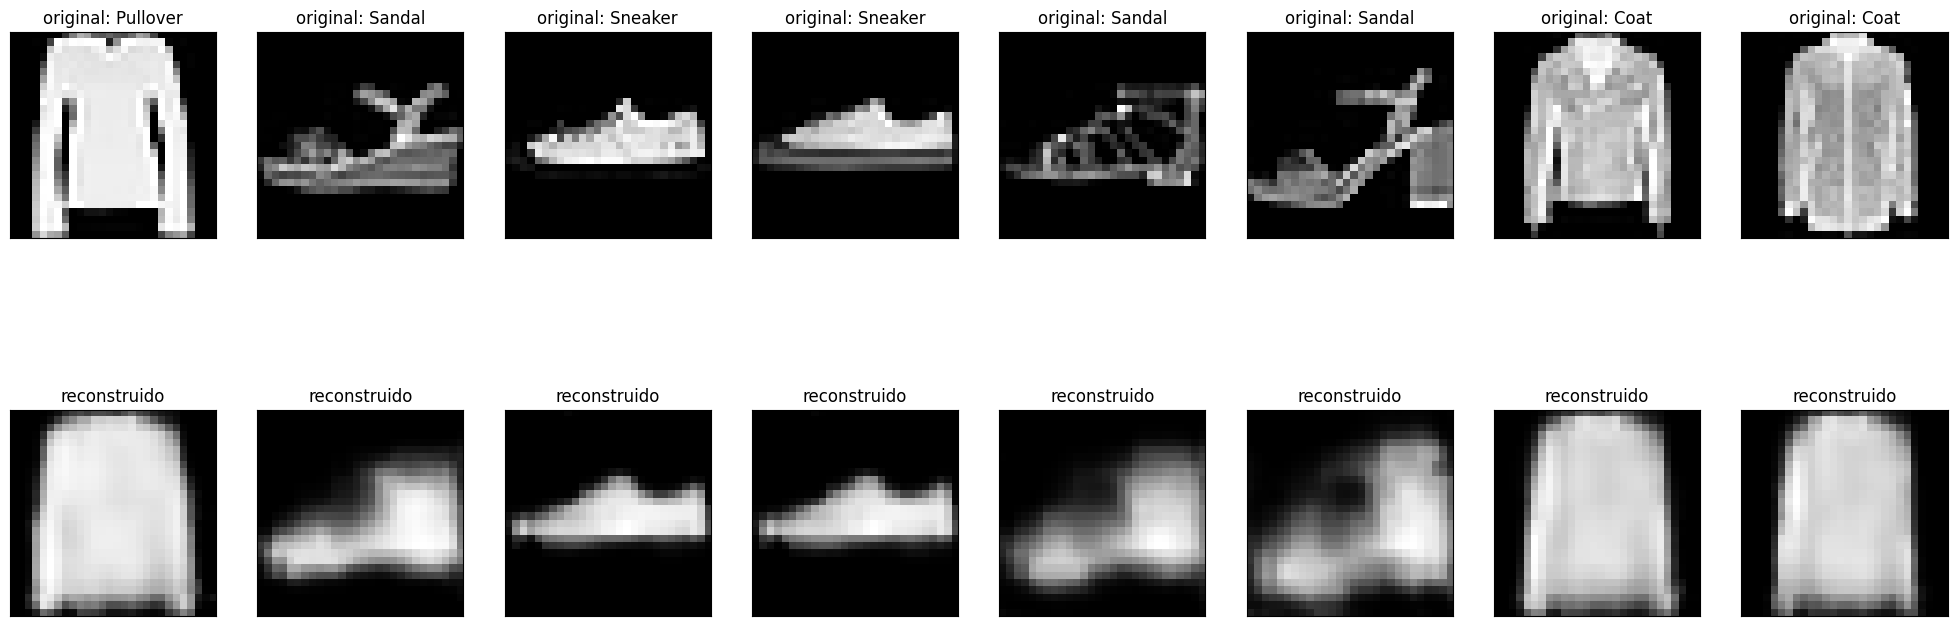

In [32]:
plt.figure(figsize=(25, 9))
for idx,(ds,lb) in enumerate(data_unseen.take(8)):
    ax = plt.subplot(2, 8, idx + 1)
    plt.title("original: {}".format(label_names[lb[0]]))
    plt.imshow(tf.squeeze(ds[0]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    bx = plt.subplot(2, 8, idx + 8 + 1)
    plt.title("reconstruido")
    plt.imshow(tf.squeeze(autoencoder.predict(ds)[0]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
    
    

In [33]:
encoder_model=tf.keras.Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('encoder').output)

In [34]:
test_img = data_test.map(lambda x,y: x) 

list_latent=[]
list_latent_label=[]


for idx,(ds,lb) in enumerate(data_unseen.take(100)):
    list_latent.append(tf.squeeze(encoder_model.predict(ds)[0]).numpy().tolist())
    list_latent_label.append(label_names[lb[0].numpy().tolist()])
def df_(list_data,list_label):
  x = []
  y = []
  for i in list_data:
    x.append(i[0])
    y.append(i[1])

  df = pd.DataFrame(list(zip(x, y,list_label)),
               columns =['x', 'y','rotulos'])
  return df

df =df_(list_latent,list_latent_label)

1/1 [==============================] - 0s 25ms/step


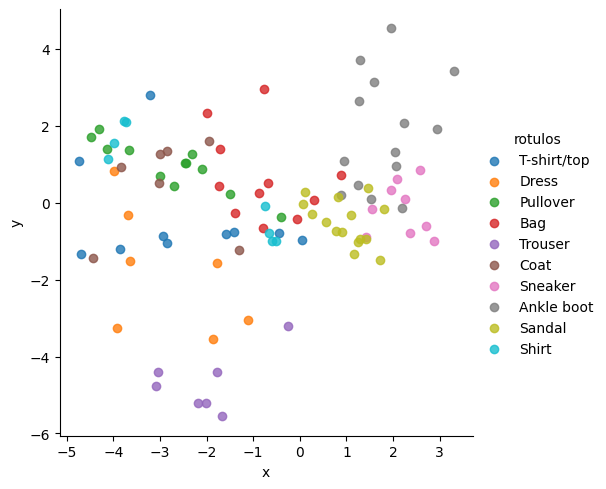

In [35]:
sns.lmplot( x="x", y="y", data=df, fit_reg=False, hue='rotulos', legend=True)

In [36]:
decoder_model=tf.keras.Model(inputs=autoencoder.get_layer('encoder').output, outputs=autoencoder.output)

1/1 [==============================] - 0s 47ms/step


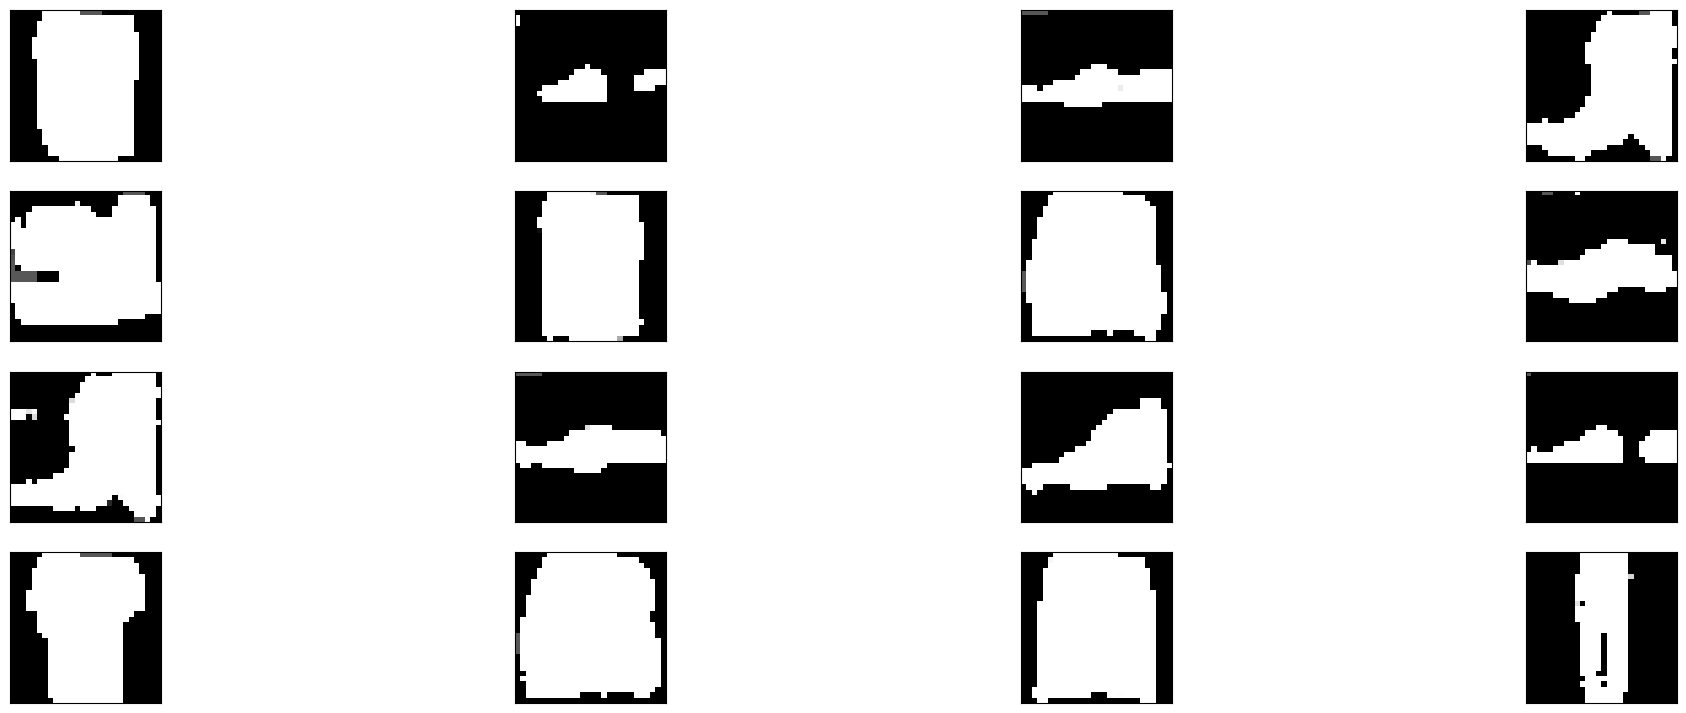

In [38]:
plt.figure(figsize=(25, 9))
for idx,ds in enumerate(range(16)):
    ax = plt.subplot(4, 4, idx + 1)
    plt.imshow(np.squeeze(decoder_model.predict(np.random.uniform(-2000,2000,size=(1, 2)).tolist())))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [39]:
def augment_data_noisy(images, labels, get_label=False):
    
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=0.3, dtype=tf.float32)
    
    if get_label:
        return tf.cast(images, tf.float32) / 255.+ noise,labels
    else:
        return tf.cast(images, tf.float32) / 255.+ noise, tf.cast(images, tf.float32) / 255.    
    

In [40]:
data_train_no = data_load(ds_train_,augmented=augment_data_noisy)
data_val_no = data_load(ds_val_,augmented=augment_data_noisy)
data_test_no = data_load(ds_test_,augmented=augment_data_noisy,shuffle_=False)
data_unseen_no = data_load(ds_unseen,augmented=augment_data_noisy,get_label=True )

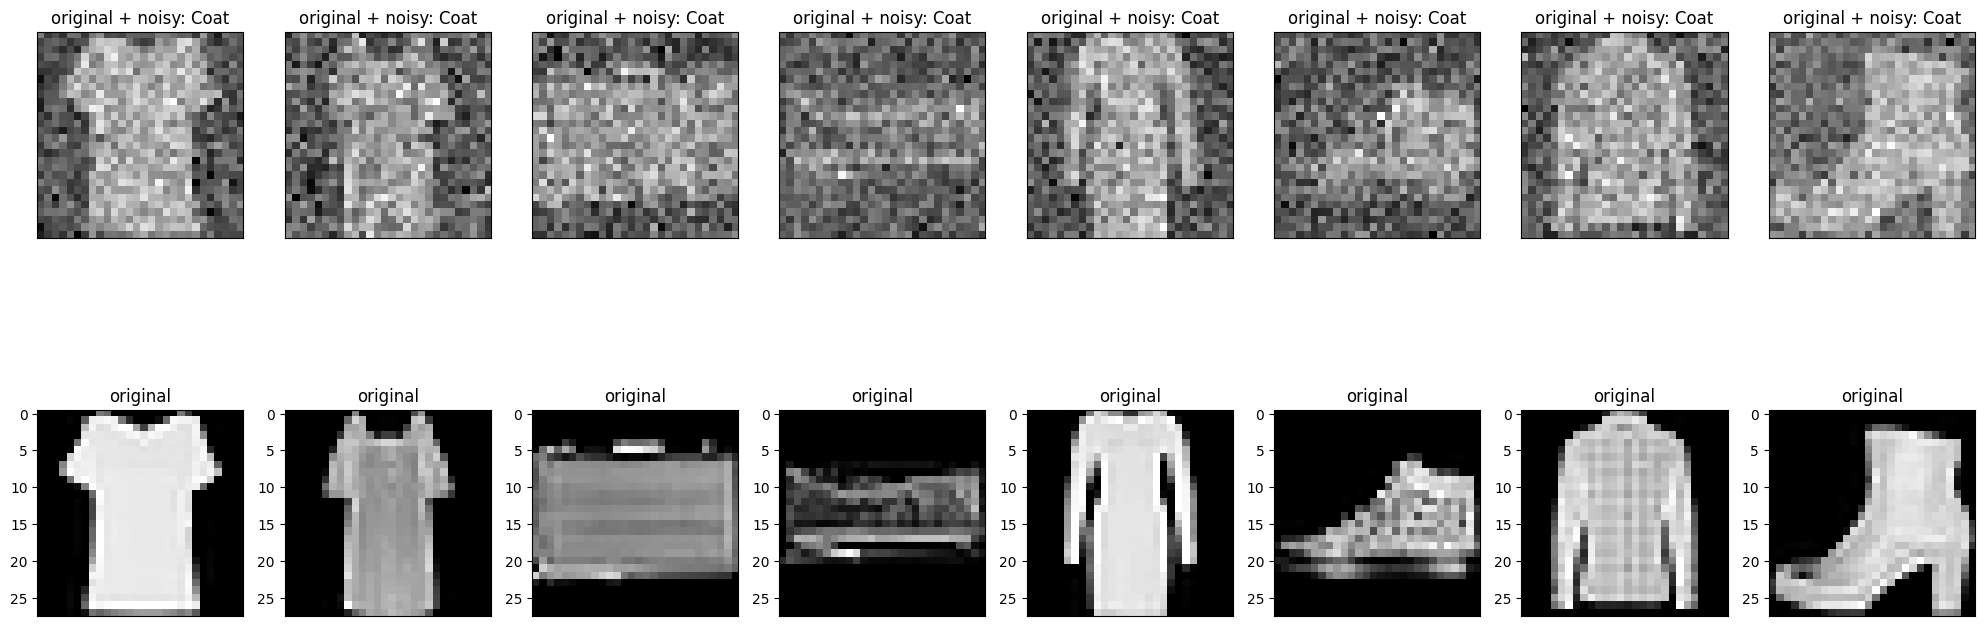

In [41]:
plt.figure(figsize=(25, 9))
for idx,(ds_no,ds) in enumerate(data_train_no.take(8)):
    ax = plt.subplot(2, 8, idx + 1)
    plt.title("original + noisy: {}".format(label_names[lb[0]]))
    plt.imshow(tf.squeeze(ds_no[0]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    bx = plt.subplot(2, 8, idx + 8 + 1)
    plt.title("original")
    plt.imshow(tf.squeeze(ds[0]))
    plt.gray()
    bx.get_xaxis().set_visible(False)

In [42]:
autoencoder_denoising= tf.keras.models.clone_model(autoencoder)

### Ahora vamos a compilar el modelo usando el optimizador Adam y la funcion de costo MSE

In [43]:
autoencoder_denoising.compile(optimizer='adam', loss='mse',metrics='accuracy')

In [44]:
autoencoder_denoising.fit(data_train_no,
                epochs=3,
                shuffle=True,
                validation_data=data_val_no,
               verbose=1)

Epoch 1/3


3000/3000 [==============================] - 22s 7ms/step - loss: 0.0442 - accuracy: 0.4945 - val_loss: 0.0376 - val_accuracy: 0.4970
Epoch 2/3
3000/3000 [==============================] - 20s 7ms/step - loss: 0.0368 - accuracy: 0.4963 - val_loss: 0.0361 - val_accuracy: 0.4974
Epoch 3/3
3000/3000 [==============================] - 20s 7ms/step - loss: 0.0357 - accuracy: 0.4970 - val_loss: 0.0351 - val_accuracy: 0.4978


1/1 [==============================] - 0s 24ms/step


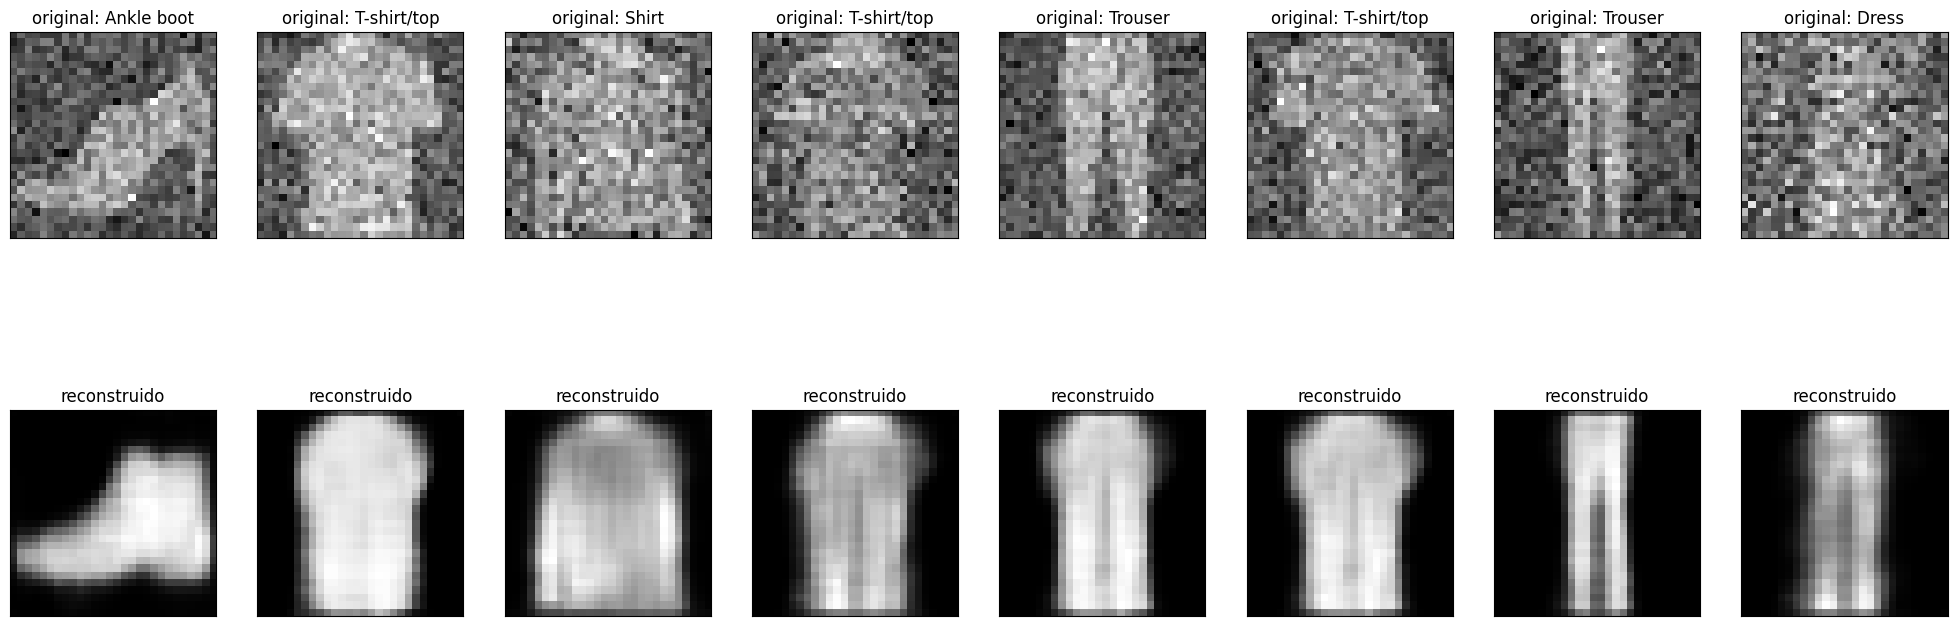

In [45]:
plt.figure(figsize=(25, 9))
for idx,(ds,lb) in enumerate(data_unseen_no.take(8)):
    ax = plt.subplot(2, 8, idx + 1)
    plt.title("original: {}".format(label_names[lb[0]]))
    plt.imshow(tf.squeeze(ds[0]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    bx = plt.subplot(2, 8, idx + 8 + 1)
    plt.title("reconstruido")
    plt.imshow(tf.squeeze(autoencoder_denoising.predict(ds)[0]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)